# Modeling

## Imports and configuration

In [ ]:
from pathlib import Path
import os
from joblib import parallel_config
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandas.tseries.holiday import USFederalHolidayCalendar
from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from scipy.stats import randint, loguniform, uniform
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.model_selection import RandomizedSearchCV
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from tqdm import tqdm

PROJECT_DIR = Path.cwd()
CPU_COUNT = 4
SEARCH_WORKERS = 2
FIGURE_DIR = PROJECT_DIR / "figures"

TWITTER_FILE = PROJECT_DIR / "total.csv"
GDELT_ELECTION_FILE = PROJECT_DIR / "GDELT_US_election.csv"
GDELT_EVENTS_FILE = PROJECT_DIR / "GDELT_US_events.csv"
ANALYSIS_START = pd.Timestamp("2019-11-30")
PRETREATMENT_END = pd.Timestamp("2021-01-05")
ROLLOUT_START = pd.Timestamp("2021-01-06")
ROLLOUT_END = pd.Timestamp("2021-01-11")
POST_START = pd.Timestamp("2021-01-12")
ANALYSIS_END = pd.Timestamp("2021-05-06")
MAX_HORIZON = 120
BRIDGE_DAYS = 28
ACTIVITY_FACTORS = 3
GDELT_COMPONENTS = 5
RATE_PRIOR = 25
SEED = 42

ACTIVITY_DISRUPTIONS = pd.DataFrame([
    {"level": "ha", "start": "2020-08-16", "end": "2020-08-18"},
    {"level": "ha", "start": "2020-10-15", "end": "2020-10-15"},
    {"level": "la", "start": "2020-10-22", "end": "2020-11-03"},
    {"level": "ma", "start": "2020-10-24", "end": "2020-10-30"},
])

ACTIVITY_DISRUPTIONS[["start", "end"]] = ACTIVITY_DISRUPTIONS[["start", "end"]].apply(pd.to_datetime)

MODEL_FAMILIES = ["ridge", "extra", "kn", "elasticnet"]
CANDIDATES = [{"candidate_id": f"{stage1}_{stage2}_{mode}", "stage1": stage1, "stage2": stage2, "mode": mode} for stage1 in MODEL_FAMILIES for stage2 in MODEL_FAMILIES for mode in ["rate", "count"]]
CANDIDATES = [dict(t) for t in set([tuple(sorted(b.items())) for b in CANDIDATES])]

STAGE1_DISTRIBUTIONS = {
    "ridge": {"model__alpha": loguniform(1e1, 0.8e3)},
    "extra": {"model__max_depth": np.arange(30, 55, 5), "model__min_samples_split": [2, 4], "model__min_samples_leaf": [3, 5], "model__max_features": uniform(.35, .58)},
    "kn": {"model__n_neighbors": randint(25, 50), "model__leaf_size": randint(24, 61)},
    "elasticnet": {"model__estimator__alpha": [1, 11, 35], "model__estimator__l1_ratio": uniform(.05, .9)}}
STAGE2_DISTRIBUTIONS = STAGE1_DISTRIBUTIONS.copy()
SEARCH_ITERATIONS = {"ridge": 4, "extra": 4, "kn": 6, "elasticnet": 6}
FACTOR_DECAYS = [.95, .99, 1.0]
COUNT_DECAYS = [.99, .995, 1.0]
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

## Data loading and panel setup

In [65]:
twitter_raw = pd.read_csv(TWITTER_FILE, parse_dates=["date"])
gdelt_election = pd.read_csv(GDELT_ELECTION_FILE, parse_dates=["date"])
gdelt_events = pd.read_csv(GDELT_EVENTS_FILE, parse_dates=["date"])
twitter_observed = twitter_raw.loc[twitter_raw["stat"].astype(str).str.lower().eq("total") & twitter_raw["date"].between(ANALYSIS_START, ANALYSIS_END)].copy()
subset_metadata = twitter_observed[["subsets", "grouping", "level"]].drop_duplicates().sort_values("subsets").reset_index(drop=True)
subset_columns = subset_metadata["subsets"].tolist()
model_dates = pd.date_range(ANALYSIS_START, ANALYSIS_END, freq="D", name="date")
complete_index = pd.MultiIndex.from_product([model_dates, subset_columns], names=["date", "subsets"]).to_frame(index=False)
twitter_observed["source_row_present"] = True
panel = complete_index.merge(subset_metadata, on="subsets", validate="many_to_one").merge(twitter_observed.drop(columns=["grouping", "level"]), on=["date", "subsets"], how="left", validate="one_to_one").sort_values(["subsets", "date"]).reset_index(drop=True)
panel["source_row_present"] = panel["source_row_present"].eq(True)
panel["structural_zero"] = panel["grouping"].eq("suspended") & panel["date"].ge(POST_START) & ~panel["source_row_present"]
panel["disruption"] = False
for disruption in ACTIVITY_DISRUPTIONS.itertuples(index=False):
    panel.loc[panel["level"].eq(disruption.level) & panel["date"].between(disruption.start, disruption.end), "disruption"] = True

def cleaned_wide(column):
    values = pd.to_numeric(panel[column], errors="coerce").copy()
    values.loc[panel["structural_zero"]] = 0
    values.loc[panel["disruption"]] = np.nan
    frame = panel[["date", "subsets"]].copy()
    frame["value"] = values
    return frame.pivot(index="date", columns="subsets", values="value").reindex(model_dates).reindex(columns=subset_columns)

misinformation = cleaned_wide("fake_merged")
activity = cleaned_wide("n")
active_users = cleaned_wide("nusers")
disruption_dates = pd.DatetimeIndex(panel.loc[panel["disruption"], "date"].drop_duplicates())

coverage = pd.DataFrame({
    "source": ["Twitter", "GDELT election", "GDELT events"],
    "start": [panel["date"].min(), gdelt_election["date"].min(), gdelt_events["date"].min()],
    "end": [panel["date"].max(), gdelt_election["date"].max(), gdelt_events["date"].max()],
    "rows": [len(panel), len(gdelt_election), len(gdelt_events)],
})
coverage

,source,start,end,rows
0,Twitter,2019-11-30,2021-05-06,7860
1,GDELT election,2019-11-30,2021-05-15,533
2,GDELT events,2019-11-30,2021-05-15,533


## GDELT transformations and pretreatment PCA

In [66]:
def logit(values):
    clipped = np.clip(values, 1e-5, 1 - 1e-5)
    return np.log(clipped / (1 - clipped))

def sigmoid(values):
    return 1 / (1 + np.exp(-np.clip(values, -30, 30)))

def calendar_features(index):
    features = pd.DataFrame(index=index)
    features["is_weekend"] = (index.dayofweek >= 5).astype(float)
    holidays = USFederalHolidayCalendar().holidays(index.min(), index.max())
    features["is_holiday"] = index.isin(holidays).astype(float)
    features["dow_sin"] = np.sin(2 * np.pi * index.dayofweek / 7)
    features["dow_cos"] = np.cos(2 * np.pi * index.dayofweek / 7)
    features["annual_sin"] = np.sin(2 * np.pi * index.dayofyear / 365.25)
    features["annual_cos"] = np.cos(2 * np.pi * index.dayofyear / 365.25)
    return features

def gdelt_blocks(election, events, index):
    election = election.set_index("date").reindex(index)
    events = events.set_index("date").reindex(index)
    election = election[[column for column in election if "election_platform" not in column]]
    events = events.drop(columns=[column for column in events if "_root_event_count" in column])
    election_attention = [column for column in election if column.startswith("us_") or column.startswith("election_")]
    political_actors = [column for column in election if column not in election_attention]
    environment_names = {"verbal_conflict_share", "material_conflict_share", "contentious_event_count", "contentious_event_share", "contentious_mention_weighted_goldstein", "violence_event_count", "violence_event_share", "violence_mention_weighted_goldstein"}
    event_environment = [column for column in events if column.startswith("us_") or column in environment_names]
    event_categories = [column for column in events if column not in event_environment]
    return {"election_attention": election[election_attention], "political_actors": election[political_actors], "event_environment": events[event_environment], "event_categories": events[event_categories]}

def transform_gdelt(frame):
    transformed = frame.astype(float).copy()
    for column in transformed:
        if column.endswith("_share") or column in {"us_negative_share", "us_positive_share", "verbal_conflict_share", "material_conflict_share"}:
            transformed[column] = logit(transformed[column].clip(1e-6, 1 - 1e-6))
        elif any(token in column for token in ["_count", "_mentions", "_articles", "_source_count", "_source_mentions", "_document_count"]):
            transformed[column] = np.log1p(transformed[column].clip(lower=0))
    return transformed

def external_features(blocks, fit_end, index):
    feature_parts = []
    artifacts = {}
    for name, block in blocks.items():
        transformed = transform_gdelt(block)
        columns = [column for column in transformed if transformed.loc[:fit_end, column].notna().sum() >= 30 and transformed.loc[:fit_end, column].nunique(dropna=True) > 1]
        transformed = transformed[columns]
        imputer = SimpleImputer(strategy="median")
        scaler = StandardScaler()
        preprocessed = scaler.fit_transform(imputer.fit_transform(transformed.loc[:fit_end]))
        components = min(GDELT_COMPONENTS, preprocessed.shape[1], preprocessed.shape[0] - 1)
        pca = PCA(n_components=components, random_state=SEED).fit(preprocessed)
        scores = pd.DataFrame(pca.transform(scaler.transform(imputer.transform(transformed))), index=index, columns=[f"{name}_pc{number}" for number in range(1, components + 1)])
        derived = pd.DataFrame(index=index)
        for column in scores:
            for lag in [1, 3, 7]:
                derived[f"{column}_lag{lag}"] = scores[column].shift(lag)
            derived[f"{column}_mean7"] = scores[column].shift(1).rolling(7, min_periods=5).mean()
            derived[f"{column}_change7"] = scores[column].shift(1) - scores[column].shift(8)
        feature_parts.append(derived)
        artifacts[name] = {"columns": columns, "variance": pca.explained_variance_ratio_}
    return calendar_features(index).join(pd.concat(feature_parts, axis=1)), artifacts

gdelt_feature_blocks = gdelt_blocks(gdelt_election, gdelt_events, model_dates)

## Activity factors and state features

In [67]:
def activity_pca(activity_frame, user_frame, fit_end):
    combined = pd.concat({"n": np.log1p(activity_frame.clip(lower=0)), "nusers": np.log1p(user_frame.clip(lower=0))}, axis=1)
    combined.columns = [f"{measure}__{subset}" for measure, subset in combined.columns]
    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()
    preprocessed = scaler.fit_transform(imputer.fit_transform(combined.loc[:fit_end]))
    pca = PCA(n_components=ACTIVITY_FACTORS, random_state=SEED).fit(preprocessed)
    factors = pd.DataFrame(pca.transform(scaler.transform(imputer.transform(combined))), index=combined.index, columns=[f"f{number}" for number in range(1, ACTIVITY_FACTORS + 1)])
    artifact = {"imputer": imputer, "scaler": scaler, "pca": pca, "columns": combined.columns.tolist(), "variance": pca.explained_variance_ratio_}
    return factors, artifact

def reconstruct_activity(factor_values, index, artifact):
    reconstructed = artifact["scaler"].inverse_transform(artifact["pca"].inverse_transform(np.asarray(factor_values)))
    frame = pd.DataFrame(reconstructed, index=index, columns=artifact["columns"])
    predicted_activity = pd.DataFrame(index=index, columns=subset_columns, dtype=float)
    predicted_users = pd.DataFrame(index=index, columns=subset_columns, dtype=float)
    for subset in subset_columns:
        predicted_activity[subset] = np.expm1(frame[f"n__{subset}"]).clip(lower=0)
        predicted_users[subset] = np.expm1(frame[f"nusers__{subset}"]).clip(lower=0)
    return predicted_activity, predicted_users

def slope(values):
    values = np.asarray(values, float)
    valid = np.isfinite(values)
    if valid.sum() < 3:
        return np.nan
    return np.polyfit(np.arange(len(values))[valid], values[valid], 1)[0]

def state_features(series, prefix):
    features = {}
    for column in series:
        for lag in [0, 1, 2, 3, 7, 14, 28]:
            features[f"{prefix}_{column}_lag{lag}"] = series[column].shift(lag)
        for window in [3, 7, 14]:
            features[f"{prefix}_{column}_mean{window}"] = series[column].rolling(window, min_periods=max(2, window // 2)).mean()
            features[f"{prefix}_{column}_slope{window}"] = series[column].rolling(window, min_periods=max(3, window // 2)).apply(slope, raw=True)
        features[f"{prefix}_{column}_sd7"] = series[column].rolling(7, min_periods=4).std()
        features[f"{prefix}_{column}_diff1"] = series[column] - series[column].shift(1)
        features[f"{prefix}_{column}_diff7"] = series[column] - series[column].shift(7)
    return pd.DataFrame(features, index=series.index)

def rate_target(outcome, exposure, fit_end):
    prior = outcome.loc[:fit_end].sum().div(exposure.loc[:fit_end].sum().replace(0, np.nan)).fillna(.001).clip(1e-5, .95)
    smoothed = outcome.add(RATE_PRIOR * prior, axis=1).div(exposure + RATE_PRIOR).clip(1e-5, 1 - 1e-5)
    return smoothed.apply(logit).where(exposure > 0), prior

def stage2_state(mode, outcome, rate, factors):
    transformed_outcome = rate if mode == "rate" else np.log1p(outcome.clip(lower=0))
    return state_features(transformed_outcome, "outcome").join(state_features(factors, "factor"))

## Direct multi-horizon training data

In [68]:
def horizon_features(horizons):
    horizons = np.asarray(horizons, float)
    damped = (1 - np.power(.97, horizons)) / (1 - .97)
    return pd.DataFrame({"horizon": horizons, "log_horizon": np.log1p(horizons), "sqrt_horizon": np.sqrt(horizons), "horizon_scaled": horizons / MAX_HORIZON, "horizon_sq": (horizons / MAX_HORIZON) ** 2, "weekly_h_sin": np.sin(2 * np.pi * horizons / 7), "weekly_h_cos": np.cos(2 * np.pi * horizons / 7), "damped_horizon": damped})

def build_direct_rows(anchor_state, target_external, target_values, train_end, stride=10, exclude_targets=None):
    feature_rows = []
    target_rows = []
    anchor_dates = []
    target_dates = []
    horizon_values = []
    for horizon in range(1, MAX_HORIZON + 1):
        anchors = anchor_state.index[anchor_state.index + pd.Timedelta(days=horizon) <= train_end][::stride]
        targets = anchors + pd.Timedelta(days=horizon)
        if exclude_targets is not None:
            keep = ~targets.isin(exclude_targets)
            anchors = anchors[keep]
            targets = targets[keep]
        if len(anchors) == 0:
            continue
        anchor_features = anchor_state.reindex(anchors).reset_index(drop=True)
        external = target_external.reindex(targets).reset_index(drop=True).add_prefix("target_")
        horizon_frame = horizon_features(np.repeat(horizon, len(anchors)))
        projections = pd.DataFrame(index=np.arange(len(anchors)))
        for column in anchor_state.columns:
            if column.endswith("_lag0"):
                base = column[:-5]
                slope_column = f"{base}_slope7"
                if slope_column in anchor_state.columns:
                    projections[f"{base}_projected"] = anchor_features[column].to_numpy() + anchor_features[slope_column].to_numpy() * horizon_frame["damped_horizon"].to_numpy()
        feature_rows.append(pd.concat([anchor_features, external, horizon_frame, projections], axis=1))
        target_rows.append(target_values.reindex(targets).reset_index(drop=True))
        anchor_dates.extend(anchors)
        target_dates.extend(targets)
        horizon_values.extend([horizon] * len(anchors))
    features = pd.concat(feature_rows, ignore_index=True)
    targets = pd.concat(target_rows, ignore_index=True)
    metadata = pd.DataFrame({"anchor_date": anchor_dates, "target_date": target_dates, "horizon": horizon_values})
    return features, targets, metadata

def prediction_rows(anchor_date, horizons, anchor_state, target_external):
    anchors = pd.DatetimeIndex([anchor_date] * len(horizons))
    targets = pd.DatetimeIndex([anchor_date + pd.Timedelta(days=int(horizon)) for horizon in horizons])
    anchor_features = anchor_state.reindex(anchors).reset_index(drop=True)
    external = target_external.reindex(targets).reset_index(drop=True).add_prefix("target_")
    horizon_frame = horizon_features(horizons)
    projections = pd.DataFrame(index=np.arange(len(horizons)))
    for column in anchor_state.columns:
        if column.endswith("_lag0"):
            base = column[:-5]
            slope_column = f"{base}_slope7"
            if slope_column in anchor_state.columns:
                projections[f"{base}_projected"] = anchor_features[column].to_numpy() + anchor_features[slope_column].to_numpy() * horizon_frame["damped_horizon"].to_numpy()
    return pd.concat([anchor_features, external, horizon_frame, projections], axis=1), targets

def augment_stage2(features, predicted_factors, activity_artifact):
    predicted_factors = predicted_factors.reset_index(drop=True)
    valid = predicted_factors.notna().all(axis=1)
    predicted_activity = pd.DataFrame(np.nan, index=np.arange(len(predicted_factors)), columns=subset_columns)
    predicted_users = predicted_activity.copy()
    if valid.any():
        valid_activity, valid_users = reconstruct_activity(predicted_factors.loc[valid].to_numpy(), predicted_factors.index[valid], activity_artifact)
        predicted_activity.loc[valid] = valid_activity.to_numpy()
        predicted_users.loc[valid] = valid_users.to_numpy()
    augmented = features.reset_index(drop=True).copy()
    for column in predicted_factors:
        augmented[f"pred_{column}"] = predicted_factors[column].to_numpy()
    for subset in subset_columns:
        augmented[f"pred_log_n_{subset}"] = np.log1p(predicted_activity[subset].to_numpy())
        augmented[f"pred_log_nusers_{subset}"] = np.log1p(predicted_users[subset].to_numpy())
    return augmented

## Stage-one and stage-two models

In [69]:
def make_model(family):
    if family == "ridge":
        return Pipeline([("scale", StandardScaler()), ("model", Ridge())])
    if family == "extra":
        return Pipeline([("model", ExtraTreesRegressor(random_state=SEED, n_jobs=1))])
    if family == "kn":
        return Pipeline([("scale", StandardScaler()), ("model", KNeighborsRegressor(n_jobs=1))])
    if family == "elasticnet":
        return Pipeline([("scale", StandardScaler()), ("model", MultiOutputRegressor(ElasticNet(max_iter=20000, random_state=SEED), n_jobs=1))])
    raise ValueError(family)

def clean_features(features):
    return features.replace([np.inf, -np.inf], np.nan).fillna(0)

def blocked_search_splits(metadata, n_splits=3):
    dates = np.sort(metadata["target_date"].unique())
    blocks = np.array_split(dates, n_splits + 1)
    splits = []
    for block in blocks[1:]:
        train = np.flatnonzero(metadata["target_date"].lt(block[0]).to_numpy())
        validate = np.flatnonzero(metadata["target_date"].between(block[0], block[-1]).to_numpy())
        if len(train) and len(validate):
            splits.append((train, validate))
    return splits

def tune_model(family, stage, features, targets, metadata):
    valid = targets.notna().all(axis=1)
    features = clean_features(features.loc[valid]).reset_index(drop=True)
    targets = targets.loc[valid].reset_index(drop=True)
    metadata = metadata.loc[valid].reset_index(drop=True)
    splits = blocked_search_splits(metadata)
    distributions = dict((STAGE1_DISTRIBUTIONS if stage == "stage1" else STAGE2_DISTRIBUTIONS)[family])
    if family == "pls":
        max_components = min(features.shape[1], len(features) - 1)
        distributions["model__n_components"] = [value for value in distributions["model__n_components"] if value <= max_components] or [1]
    if family == "kn":
        minimum_train_size = min(len(train) for train, _ in splits)
        distributions["model__n_neighbors"] = randint(3, max(4, min(41, minimum_train_size + 1)))
    n_iter = min(SEARCH_ITERATIONS[family], len(distributions["model__n_components"])) if family == "pls" else SEARCH_ITERATIONS[family]
    search = RandomizedSearchCV(make_model(family), param_distributions=distributions, n_iter=n_iter, scoring="neg_mean_absolute_error", cv=splits, n_jobs=SEARCH_WORKERS, pre_dispatch=SEARCH_WORKERS, refit=True, random_state=SEED, error_score="raise", verbose=1)
    with parallel_config(backend="loky", inner_max_num_threads=1):
        search.fit(features, targets)
    return search.best_estimator_, search.best_params_, -search.best_score_

def fit_estimator(template, features, targets):
    valid = targets.notna().all(axis=1)
    model = clone(template)
    model.fit(clean_features(features.loc[valid]), targets.loc[valid])
    return model

def predict_model(model, features):
    return model.predict(clean_features(features))

def crossfit_stage1(template, features, targets, metadata):
    predictions = np.full((len(targets), targets.shape[1]), np.nan)
    unique_targets = np.sort(metadata["target_date"].unique())
    valid_dates = unique_targets[unique_targets >= pd.Timestamp(unique_targets.min()) + pd.Timedelta(days=90)]
    for block in np.array_split(valid_dates, 2):
        if len(block) == 0:
            continue
        block_start = pd.Timestamp(block[0])
        block_end = pd.Timestamp(block[-1])
        train = metadata["target_date"] < block_start
        validate = metadata["target_date"].between(block_start, block_end)
        if train.sum() < 100 or validate.sum() == 0:
            continue
        model = fit_estimator(template, features.loc[train], targets.loc[train])
        predictions[validate] = predict_model(model, features.loc[validate])
    return pd.DataFrame(predictions, columns=targets.columns, index=targets.index)

def bridge_predictions(stage1_model, stage2_model, stage2_columns, mode, factor_state, outcome_state, external, activity_artifact, start, end):
    factor_predictions = []
    count_predictions = []
    for date in pd.date_range(start, end):
        stage1_features, _ = prediction_rows(date - pd.Timedelta(days=1), [1], factor_state, external)
        predicted_factors = pd.DataFrame(predict_model(stage1_model, stage1_features), columns=[f"f{number}" for number in range(1, ACTIVITY_FACTORS + 1)], index=[date])
        predicted_activity, _ = reconstruct_activity(predicted_factors.to_numpy(), [date], activity_artifact)
        stage2_base, _ = prediction_rows(date - pd.Timedelta(days=1), [1], outcome_state, external)
        stage2_features = augment_stage2(stage2_base, predicted_factors.reset_index(drop=True), activity_artifact).reindex(columns=stage2_columns)
        predicted_outcome = pd.DataFrame(predict_model(stage2_model, stage2_features), columns=subset_columns, index=[date])
        if mode == "rate":
            counts = predicted_activity * sigmoid(predicted_outcome)
        else:
            counts = pd.DataFrame(np.expm1(predicted_outcome.to_numpy()).clip(min=0), index=[date], columns=subset_columns).clip(upper=predicted_activity)
        factor_predictions.append(predicted_factors)
        count_predictions.append(counts)
    return pd.concat(factor_predictions), pd.concat(count_predictions)

def calibration(predicted_factors, predicted_counts, actual_factors, actual_counts):
    index = predicted_counts.index
    weights = np.power(.90, np.arange(len(index) - 1, -1, -1))
    weights = weights / weights.sum()
    factor_bias = pd.Series(np.nansum((actual_factors.reindex(index) - predicted_factors).to_numpy() * weights[:, None], axis=0), index=predicted_factors.columns)
    residuals = np.log1p(actual_counts.reindex(index)) - np.log1p(predicted_counts)
    global_bias = np.nansum(residuals.to_numpy() * weights[:, None]) / np.sum(np.isfinite(residuals.to_numpy()) * weights[:, None])
    count_bias = pd.Series(index=residuals.columns, dtype=float)
    for level, part in subset_metadata.groupby("level"):
        columns = part["subsets"].tolist()
        values = residuals[columns].to_numpy()
        level_bias = np.nansum(values * weights[:, None]) / np.sum(np.isfinite(values) * weights[:, None])
        for column in columns:
            residual = residuals[column].to_numpy()
            valid = np.isfinite(residual)
            subset_bias = np.sum(residual[valid] * weights[valid]) / weights[valid].sum() if valid.any() else level_bias
            effective_sample = 1 / np.sum(weights[valid] ** 2) if valid.any() else 0
            shrinkage = effective_sample / (effective_sample + 15)
            count_bias[column] = level_bias + shrinkage * (subset_bias - level_bias)
    return factor_bias.fillna(0), count_bias.fillna(global_bias)

def forecast(stage1_model, stage2_model, stage2_columns, mode, anchor_date, horizon, factor_state, outcome_state, external, activity_artifact, factor_bias, count_bias, factor_decay, count_decay):
    horizons = np.arange(1, horizon + 1)
    stage1_features, targets = prediction_rows(anchor_date, horizons, factor_state, external)
    raw_factors = pd.DataFrame(predict_model(stage1_model, stage1_features), index=targets, columns=[f"f{number}" for number in range(1, ACTIVITY_FACTORS + 1)])
    factor_correction = pd.DataFrame(np.power(factor_decay, horizons - 1)[:, None] * factor_bias.reindex(raw_factors.columns).to_numpy()[None, :], index=targets, columns=raw_factors.columns)
    predicted_factors = raw_factors + factor_correction
    predicted_activity, predicted_users = reconstruct_activity(predicted_factors.to_numpy(), targets, activity_artifact)
    stage2_base, _ = prediction_rows(anchor_date, horizons, outcome_state, external)
    stage2_features = augment_stage2(stage2_base, predicted_factors.reset_index(drop=True), activity_artifact).reindex(columns=stage2_columns)
    predicted_outcome = pd.DataFrame(predict_model(stage2_model, stage2_features), index=targets, columns=subset_columns)
    if mode == "rate":
        raw_counts = predicted_activity * sigmoid(predicted_outcome)
    else:
        raw_counts = pd.DataFrame(np.expm1(predicted_outcome.to_numpy()).clip(min=0), index=targets, columns=subset_columns).clip(upper=predicted_activity)
    count_correction = pd.DataFrame(np.power(count_decay, horizons - 1)[:, None] * count_bias.reindex(subset_columns).to_numpy()[None, :], index=targets, columns=subset_columns)
    predicted_counts = np.expm1(np.log1p(raw_counts) + count_correction).clip(lower=0)
    return predicted_counts, predicted_factors, predicted_activity, predicted_users

## Blocked pretreatment validation

In [70]:
def score(actual, predicted):
    actual = actual.reindex_like(predicted)
    valid = actual.notna()
    complete = actual.notna().all(axis=1)
    actual_total = actual.loc[complete].sum(axis=1)
    predicted_total = predicted.loc[complete].sum(axis=1)
    error = predicted_total - actual_total
    subset_wape = (predicted - actual).abs().where(valid).sum().div(actual.abs().where(valid).sum().replace(0, np.nan))
    actual_wave = actual_total - actual_total.rolling(7, min_periods=4).mean()
    predicted_wave = predicted_total - predicted_total.rolling(7, min_periods=4).mean()
    return {"aggregate_wape": error.abs().sum() / actual_total.abs().sum(), "mean_subset_wape": subset_wape.mean(), "bias_share": abs(error.sum()) / actual_total.abs().sum(), "wave_correlation": actual_wave.corr(predicted_wave), "daily_change_correlation": actual_total.diff().corr(predicted_total.diff()), "mean_daily_bias": error.mean(), "cumulative_gap": error.sum(), "rmse": np.sqrt(np.mean(error ** 2))}

folds = pd.DataFrame([
    {"fold": 1, "train_end": pd.Timestamp("2020-09-07"), "validation_start": pd.Timestamp("2020-09-08"), "validation_end": pd.Timestamp("2021-01-05")},
    {"fold": 2, "train_end": pd.Timestamp("2020-11-06"), "validation_start": pd.Timestamp("2020-11-07"), "validation_end": pd.Timestamp("2021-01-05")},
])

def prepare_fit(fit_end):
    external, gdelt_artifacts = external_features(gdelt_feature_blocks, fit_end, model_dates)
    factors, activity_artifact = activity_pca(activity, active_users, fit_end)
    rate, prior = rate_target(misinformation, activity, fit_end)
    factor_state = state_features(factors, "factor")
    stage1_features, stage1_targets, stage1_metadata = build_direct_rows(factor_state, external, factors, fit_end, exclude_targets=disruption_dates)
    bridge_start = fit_end - pd.Timedelta(days=BRIDGE_DAYS - 1)
    bridge_train_end = bridge_start - pd.Timedelta(days=1)
    stage2_bases = {}
    for mode in ["count", "rate"]:
        outcome = rate if mode == "rate" else np.log1p(misinformation.clip(lower=0))
        outcome_state = stage2_state(mode, misinformation, rate, factors)
        base_features, targets, metadata = build_direct_rows(outcome_state, external, outcome, fit_end, exclude_targets=disruption_dates)
        if not stage1_metadata[["anchor_date", "target_date", "horizon"]].equals(metadata[["anchor_date", "target_date", "horizon"]]):
            raise ValueError("Stage-one and stage-two rows are misaligned")
        stage2_bases[mode] = {"outcome_state": outcome_state, "features": base_features, "targets": targets, "metadata": metadata}
    return {"fit_end": fit_end, "external": external, "gdelt_artifacts": gdelt_artifacts, "factors": factors, "activity_artifact": activity_artifact, "rate": rate, "prior": prior, "factor_state": factor_state, "stage1_features": stage1_features, "stage1_targets": stage1_targets, "stage1_metadata": stage1_metadata, "stage2_bases": stage2_bases, "bridge_start": bridge_start, "bridge_train_end": bridge_train_end}

def fit_stage1(prepared, stage1_name):
    features = prepared["stage1_features"]
    targets = prepared["stage1_targets"]
    metadata = prepared["stage1_metadata"]
    bridge_mask = metadata["target_date"] <= prepared["bridge_train_end"]
    template, best_params, search_mae = tune_model(stage1_name, "stage1", features.loc[bridge_mask], targets.loc[bridge_mask], metadata.loc[bridge_mask])
    out_of_fold = crossfit_stage1(template, features, targets, metadata)
    return {"out_of_fold": out_of_fold, "valid": out_of_fold.notna().all(axis=1), "final": fit_estimator(template, features, targets), "bridge": fit_estimator(template, features.loc[bridge_mask], targets.loc[bridge_mask]), "best_params": best_params, "search_mae": search_mae}

def fit_candidate(prepared, stage1_result, candidate):
    mode = candidate["mode"]
    base = prepared["stage2_bases"][mode]
    stage2_features = augment_stage2(base["features"], stage1_result["out_of_fold"], prepared["activity_artifact"])
    valid = stage1_result["valid"] & base["targets"].notna().all(axis=1)
    bridge_valid = valid & base["metadata"]["target_date"].le(prepared["bridge_train_end"])
    template, best_params, search_mae = tune_model(candidate["stage2"], "stage2", stage2_features.loc[bridge_valid], base["targets"].loc[bridge_valid], base["metadata"].loc[bridge_valid])
    final_model = fit_estimator(template, stage2_features.loc[valid], base["targets"].loc[valid])
    bridge_model = fit_estimator(template, stage2_features.loc[bridge_valid], base["targets"].loc[bridge_valid])
    columns = stage2_features.columns.tolist()
    bridge_factors, bridge_counts = bridge_predictions(stage1_result["bridge"], bridge_model, columns, mode, prepared["factor_state"], base["outcome_state"], prepared["external"], prepared["activity_artifact"], prepared["bridge_start"], prepared["fit_end"])
    factor_bias, count_bias = calibration(bridge_factors, bridge_counts, prepared["factors"].loc[prepared["bridge_start"]:prepared["fit_end"]], misinformation.loc[prepared["bridge_start"]:prepared["fit_end"]])
    return {"candidate": candidate, "stage1_model": stage1_result["final"], "stage2_model": final_model, "stage2_columns": columns, "mode": mode, "outcome_state": base["outcome_state"], "bridge_factors": bridge_factors, "bridge_counts": bridge_counts, "factor_bias": factor_bias, "count_bias": count_bias, "stage2_best_params": best_params, "stage2_search_mae": search_mae}

folds

,fold,train_end,validation_start,validation_end
0,1,2020-09-07,2020-09-08,2021-01-05
1,2,2020-11-06,2020-11-07,2021-01-05


## Model grid evaluation and selection

In [71]:
grid_rows = []
fold_results = {}
for fold in tqdm(folds.itertuples(index=False), desc="Folds", unit="fold", total=len(folds)):
    prepared = prepare_fit(fold.train_end)
    stage1_results = {name: fit_stage1(prepared, name) for name in MODEL_FAMILIES}
    candidate_artifacts = {}
    horizon = (fold.validation_end - fold.train_end).days
    actual = misinformation.loc[fold.validation_start:fold.validation_end]
    for candidate in CANDIDATES:
        stage1_result = stage1_results[candidate["stage1"]]
        artifact = fit_candidate(prepared, stage1_result, candidate)
        predicted, _, _, _ = forecast(artifact["stage1_model"], artifact["stage2_model"], artifact["stage2_columns"], artifact["mode"], fold.train_end, horizon, prepared["factor_state"], artifact["outcome_state"], prepared["external"], prepared["activity_artifact"], artifact["factor_bias"], artifact["count_bias"], .97, .99)
        full_score = score(actual, predicted)
        short_score = score(actual.iloc[:min(60, len(actual))], predicted.iloc[:min(60, len(predicted))])
        grid_rows.append({"fold": fold.fold, "candidate_id": candidate["candidate_id"], "stage1": candidate["stage1"], "stage2": candidate["stage2"], "mode": candidate["mode"], "horizon_days": horizon, "stage1_search_mae": stage1_result["search_mae"], "stage2_search_mae": artifact["stage2_search_mae"], "stage1_params": stage1_result["best_params"], "stage2_params": artifact["stage2_best_params"], **{f"full_{key}": value for key, value in full_score.items()}, **{f"short_{key}": value for key, value in short_score.items()}})
        candidate_artifacts[candidate["candidate_id"]] = artifact
    fold_results[fold.fold] = {"prepared": prepared, "candidate_artifacts": candidate_artifacts}
    print(f"Completed candidate evaluation for fold {fold.fold}")

Folds:   0%|          | 0/2 [00:00<?, ?fold/s]

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Fitting 3 folds for each of 4 candidates

Folds:  50%|█████     | 1/2 [03:33<03:33, 213.83s/fold]

Completed candidate evaluation for fold 1
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Fitting 3 folds for each of 4 candidates, totalling 12 fit

Folds: 100%|██████████| 2/2 [09:46<00:00, 293.04s/fold]

Completed candidate evaluation for fold 2


In [72]:
grid_scores = pd.DataFrame(grid_rows)
candidate_rows = []
for candidate_id, candidate_scores in grid_scores.groupby("candidate_id"):
    long_scores = candidate_scores.loc[candidate_scores["horizon_days"].ge(120)]
    short_wape = candidate_scores["short_aggregate_wape"].mean()
    long_wape = long_scores["full_aggregate_wape"].mean()
    long_bias = long_scores["full_bias_share"].mean()
    subset_wape = candidate_scores["short_mean_subset_wape"].mean()
    wave_correlation = candidate_scores["full_wave_correlation"].mean()
    wave_penalty = (1 - np.clip(wave_correlation if pd.notna(wave_correlation) else -1, -1, 1)) / 2
    selection_score = .30 * short_wape + .35 * long_wape + .20 * long_bias + .05 * subset_wape + .10 * wave_penalty
    candidate_rows.append({"candidate_id": candidate_id, "stage1": candidate_scores["stage1"].iloc[0], "stage2": candidate_scores["stage2"].iloc[0], "mode": candidate_scores["mode"].iloc[0], "mean_60d_wape": short_wape, "mean_120d_wape": long_wape, "mean_120d_bias_share": long_bias, "mean_subset_wape": subset_wape, "mean_wave_correlation": wave_correlation, "selection_score": selection_score})
candidate_summary = pd.DataFrame(candidate_rows).sort_values("selection_score").reset_index(drop=True)
selected_candidate_id = candidate_summary.loc[0, "candidate_id"]
selected_candidate = next(candidate for candidate in CANDIDATES if candidate["candidate_id"] == selected_candidate_id)
print("Selected candidate:", selected_candidate_id)
candidate_summary.round(3)

Selected candidate: elasticnet_ridge_rate


,candidate_id,stage1,stage2,mode,mean_60d_wape,mean_120d_wape,mean_120d_bias_share,mean_subset_wape,mean_wave_correlation,selection_score
0,elasticnet_ridge_rate,elasticnet,ridge,rate,0.164,0.197,0.143,0.514,0.501,0.198
1,extra_ridge_rate,extra,ridge,rate,0.164,0.219,0.133,0.534,0.465,0.206
2,kn_ridge_rate,kn,ridge,rate,0.188,0.197,0.040,0.778,0.301,0.207
3,extra_ridge_count,extra,ridge,count,0.347,0.166,0.036,0.836,0.458,0.238
4,extra_extra_count,extra,extra,count,0.172,0.273,0.240,0.399,0.334,0.248
5,ridge_extra_count,ridge,extra,count,0.184,0.273,0.227,0.411,0.247,0.255
6,kn_extra_count,kn,extra,count,0.187,0.268,0.227,0.407,0.159,0.258
7,elasticnet_extra_count,elasticnet,extra,count,0.183,0.276,0.241,0.412,0.205,0.260
8,ridge_kn_count,ridge,kn,count,0.253,0.243,0.167,0.440,0.029,0.265
9,kn_extra_rate,kn,extra,rate,0.200,0.283,0.167,0.661,0.214,0.265


## Bridge calibration and decay evaluation

In [73]:
decay_rows = []
decay_predictions = {}
for fold in folds.itertuples(index=False):
    prepared = fold_results[fold.fold]["prepared"]
    artifact = fold_results[fold.fold]["candidate_artifacts"][selected_candidate_id]
    horizon = (fold.validation_end - fold.train_end).days
    actual = misinformation.loc[fold.validation_start:fold.validation_end]
    for factor_decay in FACTOR_DECAYS:
        for count_decay in COUNT_DECAYS:
            predicted, _, _, _ = forecast(artifact["stage1_model"], artifact["stage2_model"], artifact["stage2_columns"], artifact["mode"], fold.train_end, horizon, prepared["factor_state"], artifact["outcome_state"], prepared["external"], prepared["activity_artifact"], artifact["factor_bias"], artifact["count_bias"], factor_decay, count_decay)
            full_score = score(actual, predicted)
            short_score = score(actual.iloc[:min(60, len(actual))], predicted.iloc[:min(60, len(predicted))])
            decay_rows.append({"fold": fold.fold, "factor_decay": factor_decay, "count_decay": count_decay, **{f"full_{key}": value for key, value in full_score.items()}, **{f"short_{key}": value for key, value in short_score.items()}})
            decay_predictions[(fold.fold, factor_decay, count_decay)] = predicted
    print(f"Completed decay evaluation for fold {fold.fold}")
decay_scores = pd.DataFrame(decay_rows)
decay_summary_rows = []
for (factor_decay, count_decay), setting_scores in decay_scores.groupby(["factor_decay", "count_decay"]):
    long_scores = setting_scores.loc[setting_scores["fold"].isin([1, 2])]
    short_wape = setting_scores["short_aggregate_wape"].mean()
    long_wape = long_scores["full_aggregate_wape"].mean()
    long_bias = long_scores["full_bias_share"].mean()
    subset_wape = setting_scores["short_mean_subset_wape"].mean()
    wave_correlation = setting_scores["full_wave_correlation"].mean()
    wave_penalty = (1 - np.clip(wave_correlation if pd.notna(wave_correlation) else -1, -1, 1)) / 2
    selection_score = .30 * short_wape + .35 * long_wape + .20 * long_bias + .05 * subset_wape + .10 * wave_penalty
    decay_summary_rows.append({"factor_decay": factor_decay, "count_decay": count_decay, "mean_60d_wape": short_wape, "mean_120d_wape": long_wape, "mean_120d_bias_share": long_bias, "mean_subset_wape": subset_wape, "mean_wave_correlation": wave_correlation, "selection_score": selection_score})
decay_summary = pd.DataFrame(decay_summary_rows).sort_values("selection_score").reset_index(drop=True)
selected_factor_decay = float(decay_summary.loc[0, "factor_decay"])
selected_count_decay = float(decay_summary.loc[0, "count_decay"])
print("Selected decay parameters:", selected_factor_decay, selected_count_decay)
decay_summary.round(3)

Completed decay evaluation for fold 1
Completed decay evaluation for fold 2
Selected decay parameters: 0.95 0.99


,factor_decay,count_decay,mean_60d_wape,mean_120d_wape,mean_120d_bias_share,mean_subset_wape,mean_wave_correlation,selection_score
0,0.95,0.990,0.156,0.164,0.121,0.508,0.502,0.179
1,0.95,0.995,0.164,0.166,0.122,0.515,0.501,0.182
2,0.95,1.000,0.176,0.172,0.117,0.529,0.499,0.188
3,0.99,0.990,0.180,0.187,0.149,0.536,0.500,0.201
4,0.99,0.995,0.193,0.192,0.149,0.556,0.498,0.208
5,1.00,0.990,0.195,0.195,0.153,0.575,0.496,0.211
6,0.99,1.000,0.209,0.204,0.142,0.586,0.495,0.217
7,1.00,0.995,0.209,0.204,0.150,0.605,0.494,0.220
8,1.00,1.000,0.229,0.228,0.162,0.650,0.490,0.239


## Validation performance

In [74]:
validation_rows = []
validation_predictions = {}
validation_residuals = []
for fold in folds.itertuples(index=False):
    predicted = decay_predictions[(fold.fold, selected_factor_decay, selected_count_decay)]
    actual = misinformation.loc[fold.validation_start:fold.validation_end]
    metrics = score(actual, predicted)
    validation_rows.append({"fold": fold.fold, "horizon_days": len(predicted), "validation_start": fold.validation_start, "validation_end": fold.validation_end, **metrics})
    validation_predictions[fold.fold] = predicted
    validation_residuals.append(np.log1p(actual) - np.log1p(predicted))
validation_scores = pd.DataFrame(validation_rows)
aggregate_validation = pd.DataFrame([{
    "fold": "mean",
    "horizon_days": validation_scores["horizon_days"].mean(),
    "validation_start": pd.NaT,
    "validation_end": pd.NaT,
    **{column: validation_scores[column].mean() for column in ["aggregate_wape", "mean_subset_wape", "bias_share", "wave_correlation", "daily_change_correlation", "mean_daily_bias", "cumulative_gap", "rmse"]},
}])
validation_summary = pd.concat([validation_scores, aggregate_validation], ignore_index=True)
validation_summary.round(3)

,fold,horizon_days,validation_start,validation_end,aggregate_wape,mean_subset_wape,bias_share,wave_correlation,daily_change_correlation,mean_daily_bias,cumulative_gap,rmse
0,1,120.0,2020-09-08,2021-01-05,0.198,0.565,0.147,0.510,0.374,-1424.580,-151005.519,2447.006
1,2,60.0,2020-11-07,2021-01-05,0.131,0.647,0.095,0.495,0.411,955.248,57314.877,1636.238
2,mean,90.0,NaT,NaT,0.164,0.606,0.121,0.502,0.392,-234.666,-46845.321,2041.622


## Final selected model

In [75]:
final_prepared = prepare_fit(PRETREATMENT_END)
final_stage1 = fit_stage1(final_prepared, selected_candidate["stage1"])
final_artifact = fit_candidate(final_prepared, final_stage1, selected_candidate)
print("Selected stage-one parameters:", final_stage1["best_params"])
print("Selected stage-two parameters:", final_artifact["stage2_best_params"])
bridge_score = score(misinformation.loc[final_prepared["bridge_start"]:PRETREATMENT_END], final_artifact["bridge_counts"])
rollout_counts, rollout_factors, rollout_activity, rollout_users = forecast(final_artifact["stage1_model"], final_artifact["stage2_model"], final_artifact["stage2_columns"], final_artifact["mode"], PRETREATMENT_END, 6, final_prepared["factor_state"], final_artifact["outcome_state"], final_prepared["external"], final_prepared["activity_artifact"], final_artifact["factor_bias"], final_artifact["count_bias"], selected_factor_decay, selected_count_decay)
augmented_factors = final_prepared["factors"].copy()
augmented_factors.loc[rollout_factors.index] = rollout_factors
augmented_rate = final_prepared["rate"].copy()
rollout_smoothed_rate = rollout_counts.add(RATE_PRIOR * final_prepared["prior"], axis=1).div(rollout_activity + RATE_PRIOR).clip(1e-5, 1 - 1e-5)
augmented_rate.loc[rollout_smoothed_rate.index] = rollout_smoothed_rate.apply(logit)
post_factor_state = state_features(augmented_factors, "factor")
post_outcome_state = stage2_state("rate", misinformation, augmented_rate, augmented_factors)
post_factor_bias = final_artifact["factor_bias"] * selected_factor_decay ** 6
post_count_bias = final_artifact["count_bias"] * selected_count_decay ** 6
post_counts, post_factors, post_activity, post_users = forecast(final_artifact["stage1_model"], final_artifact["stage2_model"], final_artifact["stage2_columns"], final_artifact["mode"], ROLLOUT_END, 119, post_factor_state, post_outcome_state, final_prepared["external"], final_prepared["activity_artifact"], post_factor_bias, post_count_bias, selected_factor_decay, selected_count_decay)
counterfactual = pd.concat([rollout_counts, post_counts])
observed = misinformation.loc[ROLLOUT_START:ANALYSIS_END]
print("Activity-factor explained variance:", final_prepared["activity_artifact"]["variance"].sum().round(3))
print("Twenty-eight-day bridge WAPE:", round(bridge_score["aggregate_wape"], 3))
print("Twenty-eight-day bridge wave correlation:", round(bridge_score["wave_correlation"], 3))

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Selected stage-one parameters: {'model__estimator__alpha': 1, 'model__estimator__l1_ratio': 0.5871651421518383}
Selected stage-two parameters: {'model__alpha': 644.606791713144}
Activity-factor explained variance: 0.899
Twenty-eight-day bridge WAPE: 0.129
Twenty-eight-day bridge wave correlation: 0.393


## Effect estimates and uncertainty

In [76]:
def effect_summary(counterfactual_frame, observed_frame, start, end, label, columns=None):
    columns = counterfactual_frame.columns.tolist() if columns is None else columns
    counterfactual_period = counterfactual_frame.loc[start:end, columns]
    observed_period = observed_frame.loc[start:end, columns]
    valid = observed_period.notna()
    counterfactual_total = counterfactual_period.where(valid).sum().sum()
    observed_total = observed_period.where(valid).sum().sum()
    prevented = (counterfactual_period - observed_period).where(valid).sum().sum()
    complete_days = int(observed_period.notna().all(axis=1).sum())
    return {"period": label, "start": start, "end": end, "complete_days": complete_days, "counterfactual_misinformation": counterfactual_total, "observed_misinformation": observed_total, "misinformation_prevented": prevented, "average_daily_prevented": prevented / max(complete_days, 1), "percent_reduction": prevented / counterfactual_total if counterfactual_total else np.nan}

def residual_blocks(residual_frames, block_length=14):
    blocks = []
    for frame in residual_frames:
        complete = frame.dropna(how="any")
        centered = complete - complete.mean(axis=0)
        for start in range(len(complete) - block_length + 1):
            block = centered.iloc[start:start + block_length]
            if (block.index.to_series().diff().dropna() == pd.Timedelta(days=1)).all():
                blocks.append(block.to_numpy())
    return blocks

def bootstrap_counterfactual(point, observed_frame, residual_frames, draws=1000, block_length=14):
    rng = np.random.default_rng(SEED)
    blocks = residual_blocks(residual_frames, block_length)
    fold_means = [frame.mean(axis=0).to_numpy() for frame in residual_frames]
    horizon = len(point)
    blocks_needed = int(np.ceil(horizon / block_length))
    log_point = np.log1p(point.to_numpy())
    simulations = np.empty((draws, horizon, point.shape[1]))
    for draw in range(draws):
        selections = rng.integers(0, len(blocks), size=blocks_needed)
        noise = np.concatenate([blocks[index] for index in selections], axis=0)[:horizon]
        drift = fold_means[rng.integers(0, len(fold_means))]
        simulations[draw] = np.expm1(log_point + noise + drift[None, :]).clip(min=0)
    observed_total = observed_frame.reindex(point.index).sum(axis=1).to_numpy()
    simulated_totals = simulations.sum(axis=2)
    simulated_effects = simulated_totals - observed_total[None, :]
    band = pd.DataFrame({"date": point.index, "counterfactual_lower": np.quantile(simulated_totals, .025, axis=0), "counterfactual_median": np.quantile(simulated_totals, .5, axis=0), "counterfactual_upper": np.quantile(simulated_totals, .975, axis=0), "prevented_lower": np.quantile(simulated_effects, .025, axis=0), "prevented_median": np.quantile(simulated_effects, .5, axis=0), "prevented_upper": np.quantile(simulated_effects, .975, axis=0)})
    return simulations, band

def summarize_draws(simulations, observed_frame, point, start, end, columns, label):
    date_mask = (point.index >= start) & (point.index <= end)
    column_positions = [point.columns.get_loc(column) for column in columns]
    simulated_counterfactual = simulations[:, date_mask][:, :, column_positions].sum(axis=(1, 2))
    observed_total = observed_frame.loc[start:end, columns].sum().sum()
    simulated_effect = simulated_counterfactual - observed_total
    simulated_share = simulated_effect / simulated_counterfactual
    point_counterfactual = point.loc[start:end, columns].sum().sum()
    point_effect = (point.loc[start:end, columns] - observed_frame.loc[start:end, columns]).sum().sum()
    return {"estimand": label, "counterfactual_point": point_counterfactual, "observed": observed_total, "prevented_point": point_effect, "prevented_ci_lower": np.quantile(simulated_effect, .025), "prevented_ci_upper": np.quantile(simulated_effect, .975), "percent_reduction_point": point_effect / point_counterfactual, "percent_reduction_ci_lower": np.quantile(simulated_share, .025), "percent_reduction_ci_upper": np.quantile(simulated_share, .975)}

period_summary = pd.DataFrame([
    effect_summary(counterfactual, observed, ROLLOUT_START, ROLLOUT_END, "rollout"),
    effect_summary(counterfactual, observed, POST_START, ANALYSIS_END, "fully_treated"),
    effect_summary(counterfactual, observed, ROLLOUT_START, ANALYSIS_END, "rollout_and_post"),
])
simulations, uncertainty_band = bootstrap_counterfactual(counterfactual, observed, validation_residuals)
suspended_columns = subset_metadata.loc[subset_metadata["grouping"].eq("suspended"), "subsets"].tolist()
nonsuspended_columns = [column for column in subset_columns if column not in suspended_columns]
interval_summary = pd.DataFrame([
    summarize_draws(simulations, observed, counterfactual, POST_START, ANALYSIS_END, subset_columns, "network_total"),
    summarize_draws(simulations, observed, counterfactual, POST_START, ANALYSIS_END, suspended_columns, "direct_suspended"),
    summarize_draws(simulations, observed, counterfactual, POST_START, ANALYSIS_END, nonsuspended_columns, "spillover_nonsuspended"),
])
period_summary.round(3)

,period,start,end,complete_days,counterfactual_misinformation,observed_misinformation,misinformation_prevented,average_daily_prevented,percent_reduction
0,rollout,2021-01-06,2021-01-11,6,56342.062,36966.0,19376.062,3229.344,0.344
1,fully_treated,2021-01-12,2021-05-06,115,1027264.767,376757.0,650507.767,5656.589,0.633
2,rollout_and_post,2021-01-06,2021-05-06,121,1083606.830,413723.0,669883.830,5536.230,0.618


In [77]:
interval_summary.round(3)

,estimand,counterfactual_point,observed,prevented_point,prevented_ci_lower,prevented_ci_upper,percent_reduction_point,percent_reduction_ci_lower,percent_reduction_ci_upper
0,network_total,1027264.767,376757.0,650507.767,587231.904,1176359.985,0.633,0.609,0.757
1,direct_suspended,239041.403,0.0,239041.403,286409.432,524763.351,1.000,1.000,1.000
2,spillover_nonsuspended,788223.364,376757.0,411466.364,302392.076,656250.417,0.522,0.445,0.635


## Decompositions

In [78]:
decomposition_rows = []
for dimension in ["grouping", "level"]:
    for category, part in subset_metadata.groupby(dimension):
        row = effect_summary(counterfactual, observed, POST_START, ANALYSIS_END, f"{dimension}:{category}", part["subsets"].tolist())
        row.update({"dimension": dimension, "category": category})
        decomposition_rows.append(row)
for category, columns in [("direct_suspended", suspended_columns), ("spillover_nonsuspended", nonsuspended_columns)]:
    row = effect_summary(counterfactual, observed, POST_START, ANALYSIS_END, category, columns)
    row.update({"dimension": "effect_channel", "category": category})
    decomposition_rows.append(row)
decomposition_summary = pd.DataFrame(decomposition_rows)
decomposition_summary[["dimension", "category", "counterfactual_misinformation", "observed_misinformation", "misinformation_prevented", "percent_reduction"]].round(3)

,dimension,category,counterfactual_misinformation,observed_misinformation,misinformation_prevented,percent_reduction
0,grouping,A,50410.872,21702.0,28708.872,0.569
1,grouping,D,619694.892,288599.0,331095.892,0.534
2,grouping,F,117930.323,51901.0,66029.323,0.560
3,grouping,nfns,187.277,14555.0,-14367.723,-76.719
4,grouping,suspended,239041.403,0.0,239041.403,1.000
5,level,ha,450643.177,185700.0,264943.177,0.588
6,level,la,159669.711,32420.0,127249.711,0.797
7,level,ma,416951.880,158637.0,258314.880,0.620
8,effect_channel,direct_suspended,239041.403,0.0,239041.403,1.000
9,effect_channel,spillover_nonsuspended,788223.364,376757.0,411466.364,0.522


## Final figures and tables

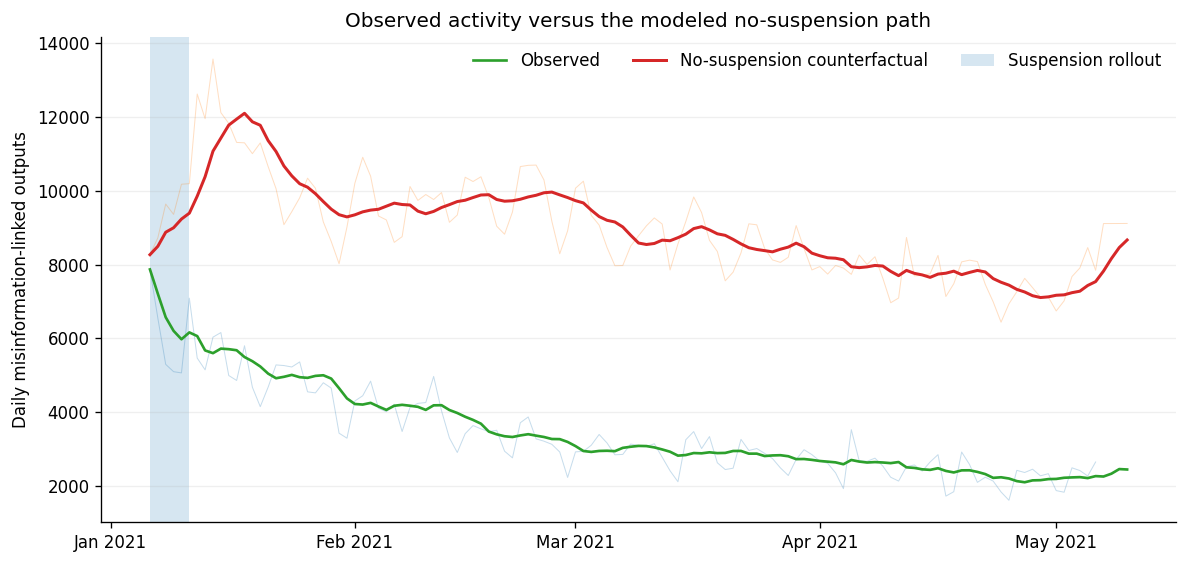

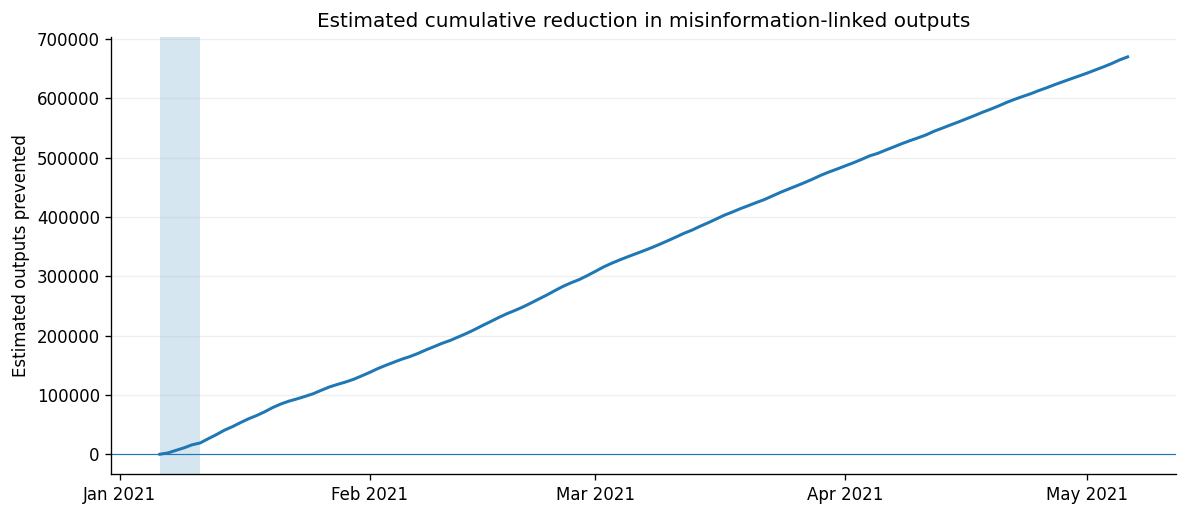

In [93]:
FIGURE_DIR.mkdir(exist_ok=True)

daily_summary = pd.DataFrame({"date": counterfactual.index, "observed_total": observed.sum(axis=1), "counterfactual_total": counterfactual.sum(axis=1)})
daily_summary["misinformation_prevented"] = daily_summary["counterfactual_total"] - daily_summary["observed_total"]
daily_summary["cumulative_prevented"] = daily_summary["misinformation_prevented"].cumsum()
daily_summary["observed_7d"] = daily_summary["observed_total"].rolling(7, min_periods=1).mean()
daily_summary["counterfactual_7d"] = daily_summary["counterfactual_total"].rolling(7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(daily_summary["date"], daily_summary["observed_total"], linewidth=.6, alpha=.25)
ax.plot(daily_summary["date"], daily_summary["counterfactual_total"], linewidth=.6, alpha=.25)
ax.plot(daily_summary["date"], daily_summary["observed_7d"], linewidth=1.6, label="Observed")
ax.plot(daily_summary["date"], daily_summary["counterfactual_7d"], linewidth=1.8, label="No-suspension counterfactual")
ax.axvspan(ROLLOUT_START, ROLLOUT_END, alpha=.18, label="Suspension rollout")
ax.set(title="Observed activity versus the modeled no-suspension path", ylabel="Daily misinformation-linked outputs")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.legend(frameon=False, ncol=3)
ax.grid(axis="y", alpha=.2)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "observed_vs_counterfactual.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

final_gap = daily_summary["cumulative_prevented"].iloc[-1]
fig, ax = plt.subplots(figsize=(10, 4.4))
ax.plot(daily_summary["date"], daily_summary["cumulative_prevented"], linewidth=1.8)
ax.axhline(0, linewidth=.7)
ax.axvspan(ROLLOUT_START, ROLLOUT_END, alpha=.18)
ax.scatter(daily_summary["date"].iloc[-1], final_gap, s=25, zorder=3)
ax.annotate(f"{final_gap:,.0f}", xy=(daily_summary["date"].iloc[-1], final_gap), xytext=(-8, 8), textcoords="offset points", ha="right")
ax.set(title="Estimated cumulative reduction in misinformation-linked outputs", ylabel="Estimated outputs prevented")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.grid(axis="y", alpha=.2)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "cumulative_prevented.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

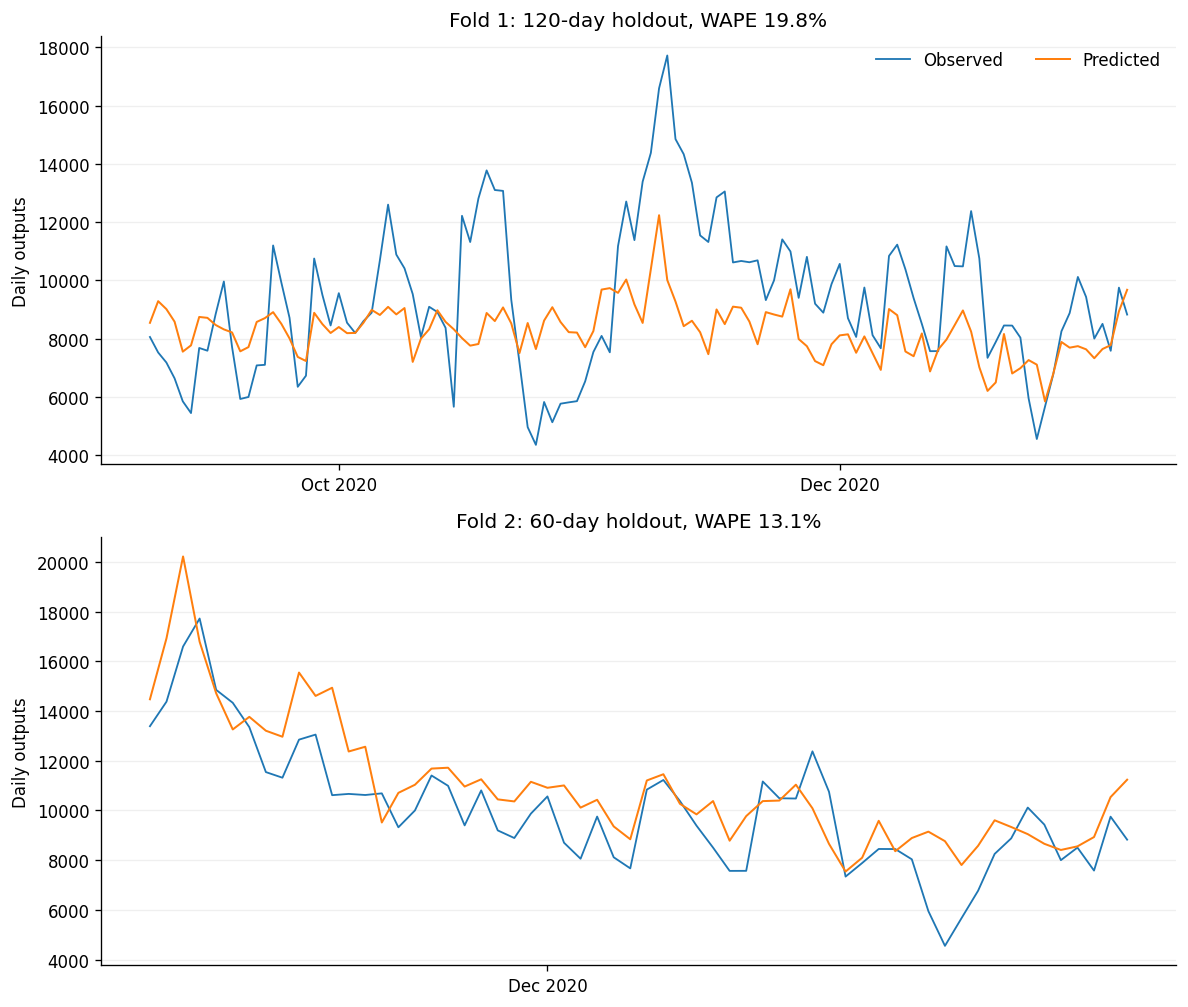

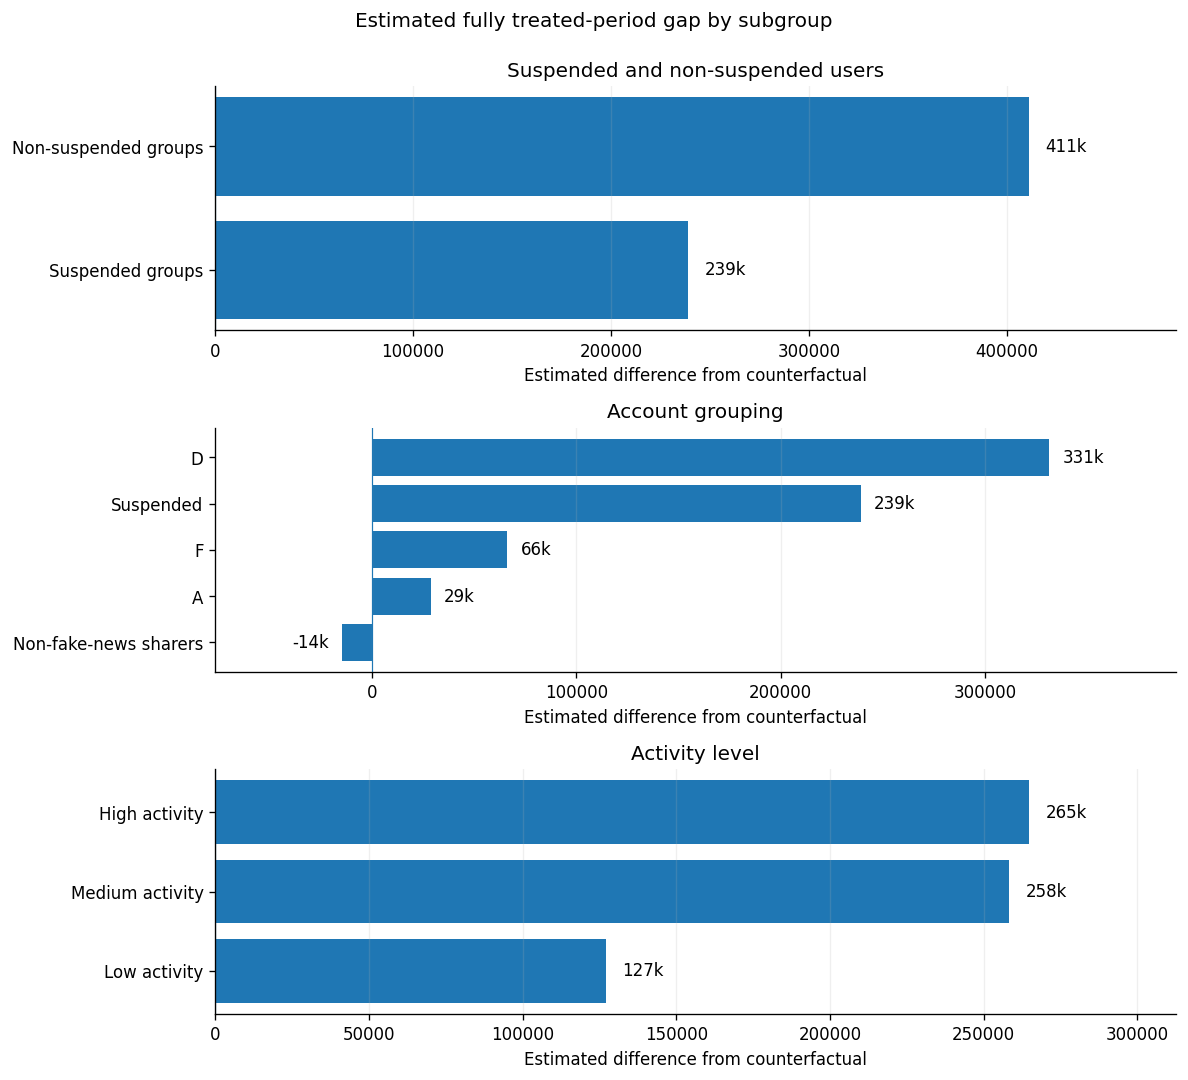

In [92]:
validation_lookup = validation_scores.set_index("fold")
fig, axes = plt.subplots(len(folds), 1, figsize=(10, 8.5))
axes = np.atleast_1d(axes)
for axis, fold in zip(axes, folds.itertuples(index=False)):
    actual = misinformation.loc[fold.validation_start:fold.validation_end].sum(axis=1, min_count=1)
    predicted = validation_predictions[fold.fold].sum(axis=1)
    axis.plot(actual, linewidth=1.1, label="Observed")
    axis.plot(predicted, linewidth=1.2, label="Predicted")
    axis.set_title(f"Fold {fold.fold}: {len(predicted)}-day holdout, WAPE {validation_lookup.loc[fold.fold, 'aggregate_wape']:.1%}")
    axis.set_ylabel("Daily outputs")
    axis.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    axis.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    axis.grid(axis="y", alpha=.2)
axes[0].legend(frameon=False, ncol=2)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "pretreatment_validation.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

channel_plot = decomposition_summary.loc[decomposition_summary["dimension"].eq("effect_channel")].copy()
channel_plot["label"] = channel_plot["category"].map({"direct_suspended": "Suspended groups", "spillover_nonsuspended": "Non-suspended groups"})
group_plot = decomposition_summary.loc[decomposition_summary["dimension"].eq("grouping")].copy()
group_plot["label"] = group_plot["category"].map({"suspended": "Suspended", "D": "D", "A": "A", "F": "F", "nfns": "Non-fake-news sharers"})
level_plot = decomposition_summary.loc[decomposition_summary["dimension"].eq("level")].copy()
level_plot["label"] = level_plot["category"].map({"ha": "High activity", "ma": "Medium activity", "la": "Low activity"})

def plot_gap(axis, data, title):
    data = data.sort_values("misinformation_prevented")
    bars = axis.barh(data["label"], data["misinformation_prevented"])
    axis.axvline(0, linewidth=.7)
    axis.set_title(title)
    axis.set_xlabel("Estimated difference from counterfactual")
    axis.grid(axis="x", alpha=.2)
    axis.margins(x=.18)
    offset = max(data["misinformation_prevented"].abs().max() * .02, 1)
    for bar, value in zip(bars, data["misinformation_prevented"]):
        axis.text(value + offset if value >= 0 else value - offset, bar.get_y() + bar.get_height() / 2, f"{value / 1000:,.0f}k", va="center", ha="left" if value >= 0 else "right")

fig, axes = plt.subplots(3, 1, figsize=(10, 9))
plot_gap(axes[0], channel_plot, "Suspended and non-suspended users")
plot_gap(axes[1], group_plot, "Account grouping")
plot_gap(axes[2], level_plot, "Activity level")
fig.suptitle("Estimated fully treated-period gap by subgroup", y=.995)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "effect_decomposition.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

In [ ]:
headline_effects = period_summary[["period", "start", "end", "counterfactual_misinformation", "observed_misinformation", "misinformation_prevented", "percent_reduction"]].copy()
validation_output = validation_summary[["fold", "horizon_days", "validation_start", "validation_end", "aggregate_wape", "bias_share", "wave_correlation"]].copy()
decomposition_output = decomposition_summary[["dimension", "category", "counterfactual_misinformation", "observed_misinformation", "misinformation_prevented", "percent_reduction"]].copy()
fully_treated_gap = headline_effects.loc[headline_effects["period"].eq("fully_treated"), "misinformation_prevented"].iloc[0]
decomposition_output["share_of_total_gap"] = decomposition_output["misinformation_prevented"].div(fully_treated_gap)

In [88]:
print(headline_effects.to_markdown(index=False))

| period           | start               | end                 |   counterfactual_misinformation |   observed_misinformation |   misinformation_prevented |   percent_reduction |
|:-----------------|:--------------------|:--------------------|--------------------------------:|--------------------------:|---------------------------:|--------------------:|
| rollout          | 2021-01-06 00:00:00 | 2021-01-11 00:00:00 |                 56342.1         |                     36966 |                    19376.1 |            0.3439   |
| fully_treated    | 2021-01-12 00:00:00 | 2021-05-06 00:00:00 |                     1.02726e+06 |                    376757 |                   650508   |            0.633243 |
| rollout_and_post | 2021-01-06 00:00:00 | 2021-05-06 00:00:00 |                     1.08361e+06 |                    413723 |                   669884   |            0.618198 |


In [86]:
print(validation_output.to_markdown(index=False))

| fold   |   horizon_days | validation_start    | validation_end      |   aggregate_wape |   bias_share |   wave_correlation |
|:-------|---------------:|:--------------------|:--------------------|-----------------:|-------------:|-------------------:|
| 1      |            120 | 2020-09-08 00:00:00 | 2021-01-05 00:00:00 |         0.19837  |    0.147171  |           0.509926 |
| 2      |             60 | 2020-11-07 00:00:00 | 2021-01-05 00:00:00 |         0.130531 |    0.0952142 |           0.494649 |
| mean   |             90 | NaT                 | NaT                 |         0.164451 |    0.121193  |           0.502288 |


In [87]:
print(decomposition_output.to_markdown(index=False))

| dimension      | category               |   counterfactual_misinformation |   observed_misinformation |   misinformation_prevented |   percent_reduction |   share_of_total_gap |
|:---------------|:-----------------------|--------------------------------:|--------------------------:|---------------------------:|--------------------:|---------------------:|
| grouping       | A                      |                       50410.9   |                     21702 |                    28708.9 |            0.569498 |            0.044133  |
| grouping       | D                      |                      619695     |                    288599 |                   331096   |            0.534289 |            0.508981  |
| grouping       | F                      |                      117930     |                     51901 |                    66029.3 |            0.559901 |            0.101504  |
| grouping       | nfns                   |                         187.277 |                     14